In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers


2026-01-31 18:45:13.468324: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-31 18:45:13.563872: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-31 18:45:15.448721: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((len(x_train), 28 * 28))
x_test = x_test.reshape((len(x_test), 28 * 28))


In [4]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values to valid range
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)


In [5]:
import matplotlib.pyplot as plt

In [6]:
autoencoder = keras.Sequential([
    layers.Input(shape=(784,)),

    # Encoder
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),   # bottleneck

    # Decoder
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid")
])


2026-01-31 18:57:49.217026: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)


In [8]:
autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)


2026-01-31 19:00:42.747933: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.
2026-01-31 19:00:54.962231: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0615 - val_loss: 0.0386
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0338 - val_loss: 0.0295
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0276 - val_loss: 0.0256
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0249 - val_loss: 0.0237
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0231 - val_loss: 0.0222


In [9]:
decoded_imgs = autoencoder.predict(x_test_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


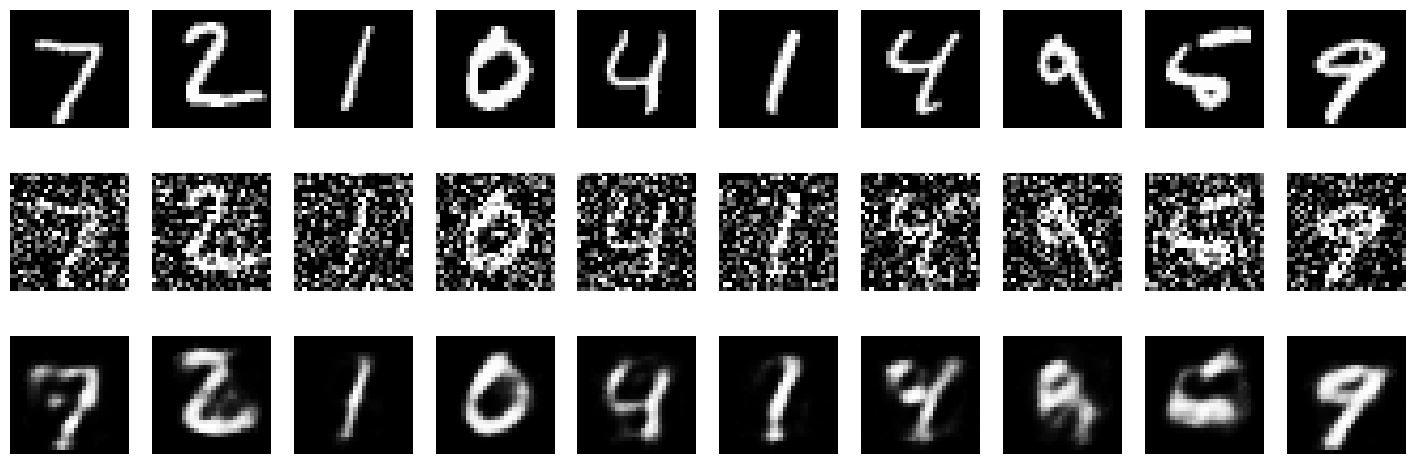

In [10]:
n = 10
plt.figure(figsize=(18, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()
